# Modern Portfolio Theory and Geometric Efficient Frontier
The premise of the Modern Portfolio Theory is simple: find a portfolio with the best expected return for a given level of risk. The founder of this theory, Harry Markowitz, suggests that a portfolio with a diversified set of assets will produce more predictable returns. This project sets out to engineer a portfolio with the highest risk-adjusted return from a small group of assets.

To begin, we must find a group of diversified assets. A diverse set of assets will be uncorrelated with one another, producing a covariance near to zero. This is shown for our group of assets by their correlation matrix.

[*********************100%***********************]  5 of 5 completed


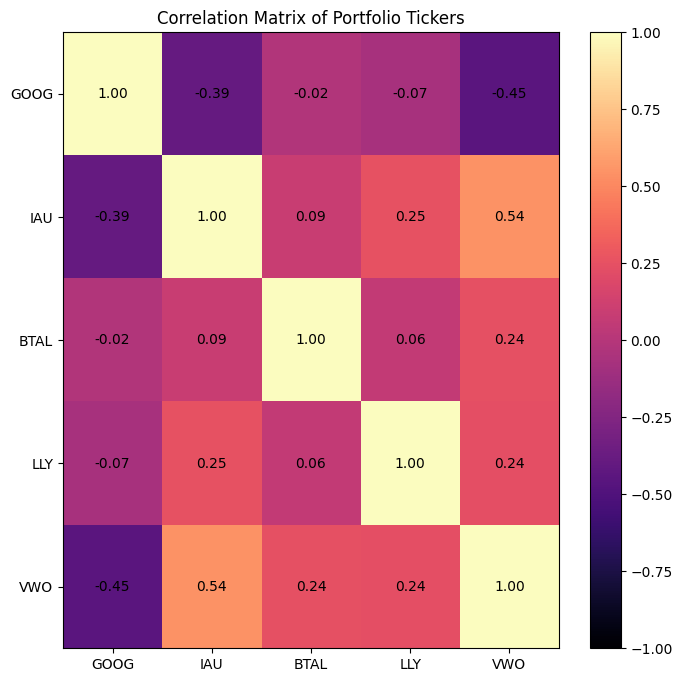

In [23]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# get data
tickers = [ "GOOG", # Tech
            "IAU", # Gold Bullion ETF
            "BTAL", # U.S. Anti-Beta Fund; long low-vol, short high-vol
            "LLY", # Health-care
            "VWO" # Emerging Markets ETF
          ]
df = yf.download(tickers, period="10y")["Close"]

# asset returns
daily_log_returns = np.log(df / df.shift(1)).dropna()
annualized_log_returns = daily_log_returns.mean() * 252


# calculate covariance matrix
cov_matrix = daily_log_returns.corr()

# plot
plt.figure(figsize=(8,8))
plt.imshow(cov_matrix, cmap="magma", aspect="auto", vmin=-1, vmax=1)
plt.colorbar()

for i in range(len(cov_matrix)):
    for j in range(len(cov_matrix)):
        plt.text(i, j, f"{cov_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.xticks(range(len(cov_matrix)), tickers)
plt.yticks(range(len(cov_matrix)), tickers)
plt.title("Correlation Matrix of Portfolio Tickers")

plt.show()

As we can observe, these tickers are uncorrelated with one another.

Let us now observe the Efficient Frontier.

In [45]:
trials = 10000
asset_returns = daily_log_returns.values # convert log returns to arithmetic
best_sharpe = -np.inf

for _ in range(trials):
    
    # create random weights
    nums = np.random.random((5, 1))

    weights = nums / nums.sum()
    
    # dot product for portfolio value
    portfolio_returns = asset_returns @ weights

    # find return
    annualized_returns = portfolio_returns.mean() * 252

    # find risk
    annualized_risk = portfolio_returns.std() * np.sqrt(252) # risk scales by sqrt(days)

    #find sharpe
    sharpe = annualized_returns / annualized_risk

    if sharpe > best_sharpe:
        best_sharpe = sharpe
        

print(best_sharpe)

1.258978671047506
